# Week 1: Global color histogram retrieval

For each QSD1 query, rank the museum database and retrieve the matching painting IDs. Week 1 evaluates visual retrieval with mAP@1 and mAP@5; artist and title metadata are not predicted.

Individual RGB is the primary method; stacked RGB and other color spaces are controlled comparisons.

## Scope and experiment sequence

The experiment progresses from individual RGB to RGB tuning, stacked RGB, and independent HSV, CIELab, and YCbCr channels. Retrieval descriptors use the original cropped images; resizing is used only for the final visualization grid.

In [1]:
from pathlib import Path
import pickle

import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 4)


def find_project_root(start=Path.cwd()):
    '''Find the repository root from the root or notebooks directory.'''
    for candidate in (start, *start.parents):
        if (candidate / "data/BBDD").is_dir() and (candidate / "data/qsd1_w1").is_dir():
            return candidate
    raise FileNotFoundError("Could not find data/BBDD and data/qsd1_w1.")


ROOT = find_project_root()
DB_DIR = ROOT / "data/BBDD"
QUERY_DIR = ROOT / "data/qsd1_w1"
DB_PATHS = sorted(DB_DIR.glob("*.jpg"))
QUERY_PATHS = sorted(QUERY_DIR.glob("*.jpg"))
DB_IDS = np.array([int(path.stem.rsplit("_", 1)[-1]) for path in DB_PATHS])
DB_PATH_BY_ID = dict(zip(DB_IDS, DB_PATHS))

with (QUERY_DIR / "gt_corresps.pkl").open("rb") as file:
    GROUND_TRUTH = pickle.load(file)

assert len(QUERY_PATHS) == len(GROUND_TRUTH)
print(f"Database: {len(DB_PATHS)} images | Queries: {len(QUERY_PATHS)} images")

Database: 287 images | Queries: 30 images


## Data inspection

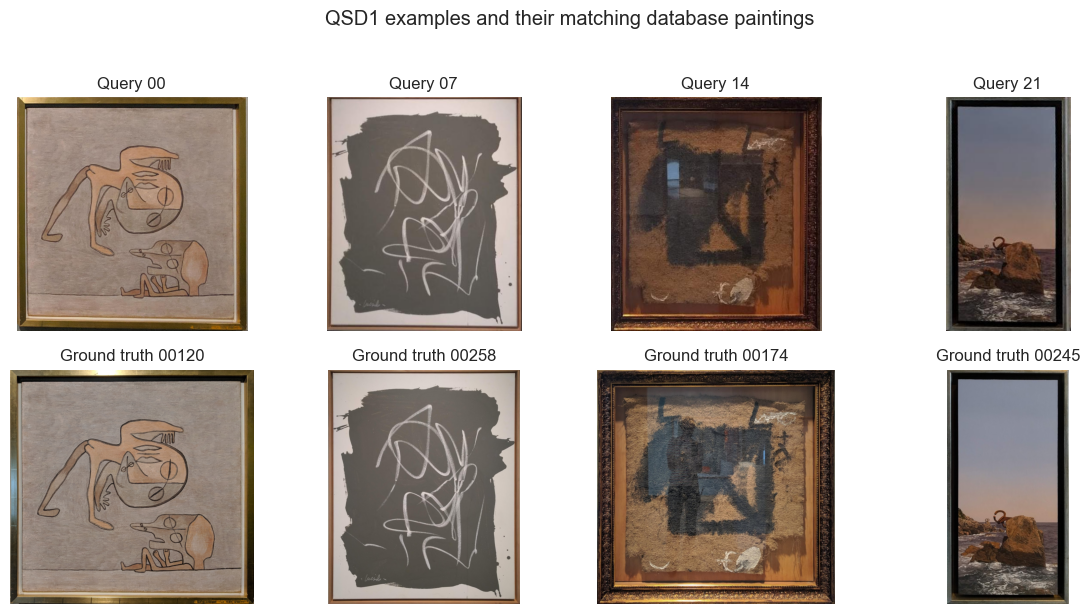

In [2]:
def read_rgb(path):
    '''Read an image and convert OpenCV BGR order to RGB.'''
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not read {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for column, query_index in enumerate([0, 7, 14, 21]):
    match_id = GROUND_TRUTH[query_index][0]
    axes[0, column].imshow(read_rgb(QUERY_PATHS[query_index]))
    axes[0, column].set_title(f"Query {query_index:02d}")
    axes[1, column].imshow(read_rgb(DB_PATH_BY_ID[match_id]))
    axes[1, column].set_title(f"Ground truth {match_id:05d}")

for axis in axes.flat:
    axis.axis("off")
fig.suptitle("QSD1 examples and their matching database paintings", y=1.02)
plt.tight_layout()
plt.show()

## Shared retrieval and evaluation functions

All histograms are L1-normalized, so image resolution does not affect their total mass. All comparison functions return a distance; lower values rank first.

In [3]:
BASE_BINS = 256
EPSILON = 1e-10
DISTANCE_METRICS = ("Euclidean", "L1", "Chi-square", "Intersection", "Hellinger")


def normalized_histogram(values, bins=BASE_BINS):
    '''Return an L1-normalized 1D intensity histogram.'''
    histogram = np.bincount(values.ravel(), minlength=bins).astype(np.float64)
    return histogram / histogram.sum()


def build_histogram_bank(paths, channel_extractor):
    '''Extract independent channel histograms in one image-loading pass.'''
    bank = None
    for path in paths:
        channels = channel_extractor(read_rgb(path))
        if bank is None:
            bank = {name: [] for name in channels}
        for name, values in channels.items():
            bank[name].append(normalized_histogram(values))
    return {name: np.stack(histograms) for name, histograms in bank.items()}


def merge_histogram_bins(histograms, bins):
    '''Merge a 256-bin histogram into a smaller number of equal-width bins.'''
    if BASE_BINS % bins != 0:
        raise ValueError(f"{bins} must divide {BASE_BINS}.")
    return histograms.reshape(len(histograms), bins, BASE_BINS // bins).sum(axis=2)


def smooth_histograms(histograms, sigma):
    '''Apply light 1D Gaussian smoothing across neighboring histogram bins.'''
    if sigma == 0:
        return histograms
    radius = max(1, int(np.ceil(3 * sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (offsets / sigma) ** 2)
    kernel /= kernel.sum()
    padded = np.pad(histograms, ((0, 0), (radius, radius)), mode="reflect")
    smoothed = np.stack([
        np.convolve(histogram, kernel, mode="valid") for histogram in padded
    ])
    return smoothed / smoothed.sum(axis=1, keepdims=True)


def pairwise_distances(queries, database, metric):
    '''Compare every query histogram with every database histogram.'''
    query = queries[:, None, :]
    reference = database[None, :, :]
    difference = query - reference

    if metric == "Euclidean":
        return np.sqrt(np.sum(difference**2, axis=2))
    if metric == "L1":
        return np.sum(np.abs(difference), axis=2)
    if metric == "Chi-square":
        return np.sum(difference**2 / (query + reference + EPSILON), axis=2)
    if metric == "Intersection":
        return 1.0 - np.sum(np.minimum(query, reference), axis=2)
    if metric == "Hellinger":
        coefficient = np.sum(np.sqrt(query * reference), axis=2)
        return np.sqrt(np.clip(1.0 - coefficient, 0.0, 1.0))
    raise ValueError(f"Unknown metric: {metric}")


def average_precision_at_k(relevant_ids, ranked_ids, k):
    '''Average precision for one query, truncated at k.'''
    relevant = set(relevant_ids)
    if not relevant:
        return 0.0
    hits = 0
    score = 0.0
    for rank, image_id in enumerate(ranked_ids[:k], start=1):
        if image_id in relevant:
            hits += 1
            score += hits / rank
    return score / min(len(relevant), k)


def mean_average_precision(rankings, k):
    scores = [
        average_precision_at_k(relevant, ranked, k)
        for relevant, ranked in zip(GROUND_TRUTH, rankings)
    ]
    return float(np.mean(scores))


def evaluate_configuration(database_bank, query_bank, channel, bins, metric, sigma=0):
    database = smooth_histograms(merge_histogram_bins(database_bank[channel], bins), sigma)
    queries = smooth_histograms(merge_histogram_bins(query_bank[channel], bins), sigma)
    distances = pairwise_distances(queries, database, metric)
    order = np.argsort(distances, axis=1)
    rankings = DB_IDS[order]
    ranked_distances = np.take_along_axis(distances, order, axis=1)
    correct_ranks = np.array([
        min(np.flatnonzero(np.isin(ranking, relevant))) + 1
        for ranking, relevant in zip(rankings, GROUND_TRUTH)
    ])
    return {
        "rankings": rankings,
        "ranked_distances": ranked_distances,
        "correct_ranks": correct_ranks,
        "mAP@1": mean_average_precision(rankings, 1),
        "mAP@5": mean_average_precision(rankings, 5),
        "median_rank": float(np.median(correct_ranks)),
    }


def run_grid(database_bank, query_bank, channels, bin_counts, sigmas=(0,)):
    '''Evaluate a compact parameter grid and return a sorted table.'''
    records = []
    for channel in channels:
        for bins in bin_counts:
            for sigma in sigmas:
                for metric in DISTANCE_METRICS:
                    evaluation = evaluate_configuration(
                        database_bank, query_bank, channel, bins, metric, sigma
                    )
                    records.append({
                        "channel": channel,
                        "bins": bins,
                        "sigma": sigma,
                        "metric": metric,
                        "mAP@1": evaluation["mAP@1"],
                        "mAP@5": evaluation["mAP@5"],
                        "median_rank": evaluation["median_rank"],
                    })
    return (
        pd.DataFrame(records)
        .sort_values(["mAP@1", "mAP@5", "median_rank"], ascending=[False, False, True])
        .reset_index(drop=True)
    )


def best_per_channel(results, channel_order):
    best = results.groupby("channel", sort=False).head(1).set_index("channel")
    return best.reindex(channel_order)

# Experiment 1: RGB channels

R, G, and B are treated as three independent descriptors. This is the primary experiment and directly matches the assigned RGB, non-stacked task.

In [4]:
RGB_CHANNELS = ("R", "G", "B")
RGB_COLORS = {"R": "tab:red", "G": "tab:green", "B": "tab:blue"}


def extract_rgb_channels(image):
    return {"R": image[:, :, 0], "G": image[:, :, 1], "B": image[:, :, 2]}


RGB_DB = build_histogram_bank(DB_PATHS, extract_rgb_channels)
RGB_QUERIES = build_histogram_bank(QUERY_PATHS, extract_rgb_channels)
print({channel: descriptors.shape for channel, descriptors in RGB_DB.items()})

{'R': (287, 256), 'G': (287, 256), 'B': (287, 256)}


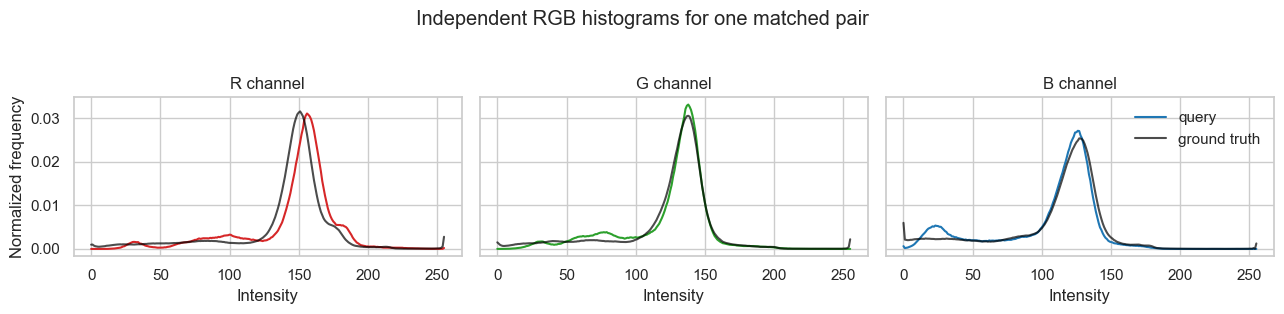

In [5]:
query_index = 0
match_id = GROUND_TRUTH[query_index][0]

fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for axis, channel in zip(axes, RGB_CHANNELS):
    axis.plot(RGB_QUERIES[channel][query_index], color=RGB_COLORS[channel], label="query")
    axis.plot(RGB_DB[channel][match_id], color="black", alpha=0.7, label="ground truth")
    axis.set(title=f"{channel} channel", xlabel="Intensity")
axes[0].set_ylabel("Normalized frequency")
axes[-1].legend(frameon=False)
fig.suptitle("Independent RGB histograms for one matched pair", y=1.04)
plt.tight_layout()
plt.show()

## RGB baseline

The baseline uses the bin counts introduced in the original experiment and no histogram smoothing.

In [6]:
BASELINE_BINS = (16, 32, 64, 128, 256)
rgb_baseline_results = run_grid(
    RGB_DB, RGB_QUERIES, RGB_CHANNELS, BASELINE_BINS, sigmas=(0,)
)
rgb_baseline_best = best_per_channel(rgb_baseline_results, RGB_CHANNELS)
display(rgb_baseline_best[["bins", "metric", "mAP@1", "mAP@5", "median_rank"]])

,bins,metric,mAP@1,mAP@5,median_rank
channel,,,,,
R,256,L1,0.2667,0.3278,33.5
G,16,Hellinger,0.3000,0.3400,10.5
B,16,Euclidean,0.1333,0.1761,37.0


## RGB tuning

The tuned grid adds coarser histograms and light Gaussian smoothing in histogram space. It does not alter the input images.

,bins,sigma,metric,mAP@1,mAP@5,median_rank
channel,,,,,,
R,8,0.0,Chi-square,0.2667,0.3389,8.5
G,16,0.5,Hellinger,0.3333,0.3567,12.5
B,8,0.5,Euclidean,0.1667,0.1844,30.0


baseline           tuned        
           mAP@1   mAP@5   mAP@1   mAP@5
channel                                 
R         0.2667  0.3278  0.2667  0.3389
G         0.3000  0.3400  0.3333  0.3567
B         0.1333  0.1761  0.1667  0.1844

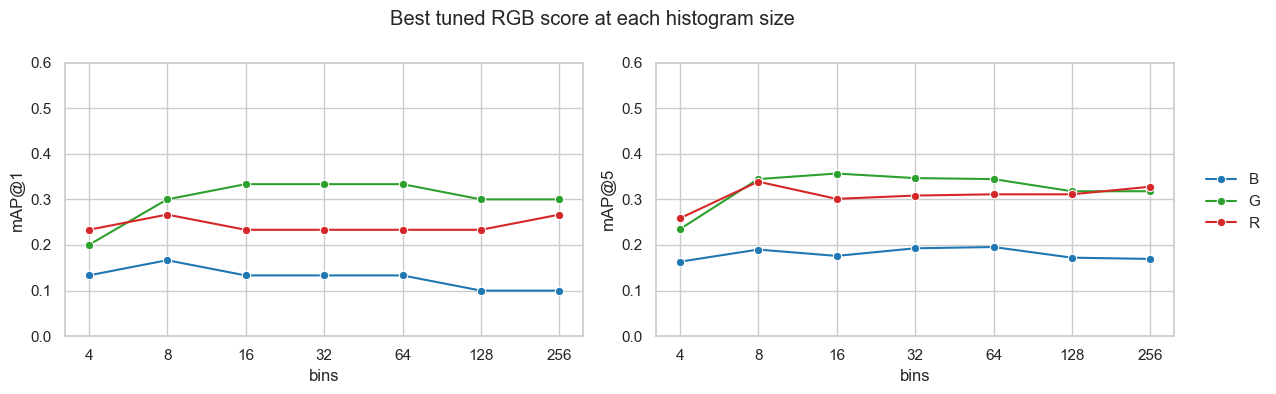

In [7]:
TUNED_BINS = (4, 8, 16, 32, 64, 128, 256)
SMOOTHING_SIGMAS = (0, 0.5, 1.0)

rgb_tuned_results = run_grid(
    RGB_DB, RGB_QUERIES, RGB_CHANNELS, TUNED_BINS, SMOOTHING_SIGMAS
)
rgb_tuned_best = best_per_channel(rgb_tuned_results, RGB_CHANNELS)
display(rgb_tuned_best[["bins", "sigma", "metric", "mAP@1", "mAP@5", "median_rank"]])

comparison = pd.concat(
    {
        "baseline": rgb_baseline_best[["mAP@1", "mAP@5"]],
        "tuned": rgb_tuned_best[["mAP@1", "mAP@5"]],
    },
    axis=1,
)
display(comparison)

rgb_envelope = (
    rgb_tuned_results.groupby(["channel", "bins"], as_index=False)[["mAP@1", "mAP@5"]]
    .max()
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, score in zip(axes, ["mAP@1", "mAP@5"]):
    sns.lineplot(
        data=rgb_envelope, x="bins", y=score, hue="channel",
        marker="o", palette=RGB_COLORS, ax=axis
    )
    axis.set_xscale("log", base=2)
    axis.set_xticks(TUNED_BINS, TUNED_BINS)
    axis.set_ylim(0, 0.6)
    axis.legend().remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle("Best tuned RGB score at each histogram size")
plt.tight_layout()
plt.show()

## Stacked RGB comparison

The R, G, and B histograms are concatenated after binning and optional smoothing, then L1-normalized. Individual RGB remains the primary assigned method.

In [8]:
def stacked_rgb_descriptors(histogram_bank, bins, sigma):
    '''Concatenate R, G, and B histograms and normalize the final vector.'''
    components = [
        smooth_histograms(merge_histogram_bins(histogram_bank[channel], bins), sigma)
        for channel in RGB_CHANNELS
    ]
    descriptors = np.concatenate(components, axis=1)
    return descriptors / descriptors.sum(axis=1, keepdims=True)


def evaluate_stacked_rgb(bins, metric, sigma=0):
    database = stacked_rgb_descriptors(RGB_DB, bins, sigma)
    queries = stacked_rgb_descriptors(RGB_QUERIES, bins, sigma)
    distances = pairwise_distances(queries, database, metric)
    order = np.argsort(distances, axis=1)
    rankings = DB_IDS[order]
    ranked_distances = np.take_along_axis(distances, order, axis=1)
    correct_ranks = np.array([
        min(np.flatnonzero(np.isin(ranking, relevant))) + 1
        for ranking, relevant in zip(rankings, GROUND_TRUTH)
    ])
    return {
        "rankings": rankings,
        "ranked_distances": ranked_distances,
        "correct_ranks": correct_ranks,
        "mAP@1": mean_average_precision(rankings, 1),
        "mAP@5": mean_average_precision(rankings, 5),
        "median_rank": float(np.median(correct_ranks)),
    }


stacked_records = []
for bins in TUNED_BINS:
    for sigma in SMOOTHING_SIGMAS:
        for metric in DISTANCE_METRICS:
            evaluation = evaluate_stacked_rgb(bins, metric, sigma)
            stacked_records.append({
                "descriptor": "RGB stacked",
                "bins": bins,
                "sigma": sigma,
                "metric": metric,
                "mAP@1": evaluation["mAP@1"],
                "mAP@5": evaluation["mAP@5"],
                "median_rank": evaluation["median_rank"],
            })

stacked_rgb_results = (
    pd.DataFrame(stacked_records)
    .sort_values(["mAP@1", "mAP@5", "median_rank"], ascending=[False, False, True])
    .reset_index(drop=True)
)
best_stacked_rgb = stacked_rgb_results.iloc[0]

display(pd.DataFrame([
    {
        "descriptor": f"Individual {rgb_tuned_results.iloc[0].channel}",
        **rgb_tuned_results.iloc[0][["bins", "sigma", "metric", "mAP@1", "mAP@5"]].to_dict(),
    },
    best_stacked_rgb[["descriptor", "bins", "sigma", "metric", "mAP@1", "mAP@5"]].to_dict(),
]))

,descriptor,bins,sigma,metric,mAP@1,mAP@5
0,Individual G,16,0.5,Hellinger,0.3333,0.3567
1,RGB stacked,8,0.0,Hellinger,0.4333,0.4500


# Experiment 2: Other color spaces

The same global 1D experiment is applied to each channel independently. These are comparisons with the RGB baseline, not stacked descriptors.

In [9]:
HSV_CHANNELS = ("HSV-H", "HSV-S", "HSV-V")
LAB_CHANNELS = ("Lab-L", "Lab-a", "Lab-b")
YCBCR_CHANNELS = ("YCbCr-Y", "YCbCr-Cb", "YCbCr-Cr")
REFERENCE_CHANNELS = ("Gray",)
ALTERNATIVE_CHANNELS = HSV_CHANNELS + LAB_CHANNELS + YCBCR_CHANNELS + REFERENCE_CHANNELS


def extract_alternative_channels(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    ycbcr = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    hue = np.rint(hsv[:, :, 0].astype(np.float32) * 255 / 179).astype(np.uint8)
    return {
        "HSV-H": hue,
        "HSV-S": hsv[:, :, 1],
        "HSV-V": hsv[:, :, 2],
        "Lab-L": lab[:, :, 0],
        "Lab-a": lab[:, :, 1],
        "Lab-b": lab[:, :, 2],
        "YCbCr-Y": ycbcr[:, :, 0],
        "YCbCr-Cb": ycbcr[:, :, 2],
        "YCbCr-Cr": ycbcr[:, :, 1],
        "Gray": cv2.cvtColor(image, cv2.COLOR_RGB2GRAY),
    }


ALT_DB = build_histogram_bank(DB_PATHS, extract_alternative_channels)
ALT_QUERIES = build_histogram_bank(QUERY_PATHS, extract_alternative_channels)
alternative_results = run_grid(
    ALT_DB, ALT_QUERIES, ALTERNATIVE_CHANNELS, TUNED_BINS, SMOOTHING_SIGMAS
)
alternative_best = best_per_channel(alternative_results, ALTERNATIVE_CHANNELS)

## HSV

In [10]:
display(alternative_best.loc[list(HSV_CHANNELS), [
    "bins", "sigma", "metric", "mAP@1", "mAP@5", "median_rank"
]])

,bins,sigma,metric,mAP@1,mAP@5,median_rank
channel,,,,,,
HSV-H,256,0.0,L1,0.3667,0.3917,11.5
HSV-S,16,0.0,Chi-square,0.4000,0.4400,6.5
HSV-V,32,0.5,Hellinger,0.2333,0.2928,18.5


## CIELab

In [11]:
display(alternative_best.loc[list(LAB_CHANNELS), [
    "bins", "sigma", "metric", "mAP@1", "mAP@5", "median_rank"
]])

,bins,sigma,metric,mAP@1,mAP@5,median_rank
channel,,,,,,
Lab-L,32,1.0,Euclidean,0.3333,0.3444,17.5
Lab-a,128,0.5,Hellinger,0.5000,0.5317,1.5
Lab-b,64,0.0,Hellinger,0.4333,0.4661,4.5


## YCbCr and grayscale reference

In [12]:
display(alternative_best.loc[list(YCBCR_CHANNELS + REFERENCE_CHANNELS), [
    "bins", "sigma", "metric", "mAP@1", "mAP@5", "median_rank"
]])

,bins,sigma,metric,mAP@1,mAP@5,median_rank
channel,,,,,,
YCbCr-Y,16,0.5,L1,0.3,0.3222,15.0
YCbCr-Cb,64,0.0,Chi-square,0.4,0.4472,3.5
YCbCr-Cr,128,1.0,Hellinger,0.4,0.4611,2.5
Gray,16,0.5,L1,0.3,0.3222,15.0


## Cross-color-space comparison

,channel,bins,sigma,metric,mAP@1,mAP@5,median_rank
0,Lab-a,128,0.5,Hellinger,0.5000,0.5317,1.5
1,Lab-b,64,0.0,Hellinger,0.4333,0.4661,4.5
2,YCbCr-Cr,128,1.0,Hellinger,0.4000,0.4611,2.5
3,YCbCr-Cb,64,0.0,Chi-square,0.4000,0.4472,3.5
4,HSV-S,16,0.0,Chi-square,0.4000,0.4400,6.5
5,HSV-H,256,0.0,L1,0.3667,0.3917,11.5
6,G,16,0.5,Hellinger,0.3333,0.3567,12.5
7,Lab-L,32,1.0,Euclidean,0.3333,0.3444,17.5
8,YCbCr-Y,16,0.5,L1,0.3000,0.3222,15.0
9,Gray,16,0.5,L1,0.3000,0.3222,15.0


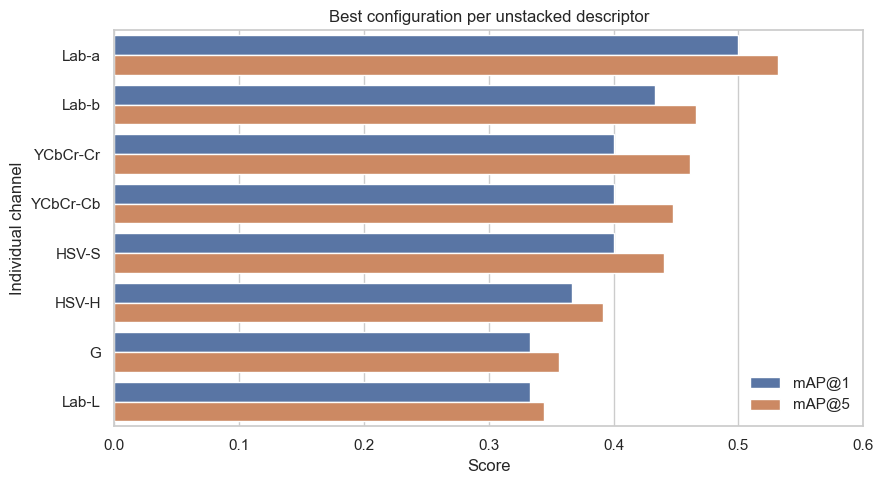

In [13]:
all_best = pd.concat([
    rgb_tuned_best.reset_index(),
    alternative_best.reset_index(),
]).sort_values(["mAP@1", "mAP@5"], ascending=False).reset_index(drop=True)

display(all_best.head(10)[[
    "channel", "bins", "sigma", "metric", "mAP@1", "mAP@5", "median_rank"
]])

plot_data = all_best.head(8).melt(
    id_vars="channel", value_vars=["mAP@1", "mAP@5"],
    var_name="score", value_name="value"
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, y="channel", x="value", hue="score")
plt.xlim(0, 0.6)
plt.xlabel("Score")
plt.ylabel("Individual channel")
plt.title("Best configuration per unstacked descriptor")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Retrieval examples: best individual RGB

Ten evenly spaced QSD1 queries are shown with their top-5 database results. Every result is labelled by its database ID; a bright green border indicates that the retrieved ID matches the ground truth.

,method,mAP@1,mAP@5,median GT rank
0,Individual G,0.3333,0.3567,12.5
1,Stacked RGB,0.4333,0.4500,5.5
2,Best Lab-a,0.5000,0.5317,1.5


Individual RGB and Lab-a agree on the top result for 13.3% of queries; mean top-5 overlap is 10.0%.
Displayed query indices: [0, 3, 6, 9, 12, 16, 19, 22, 25, 29]


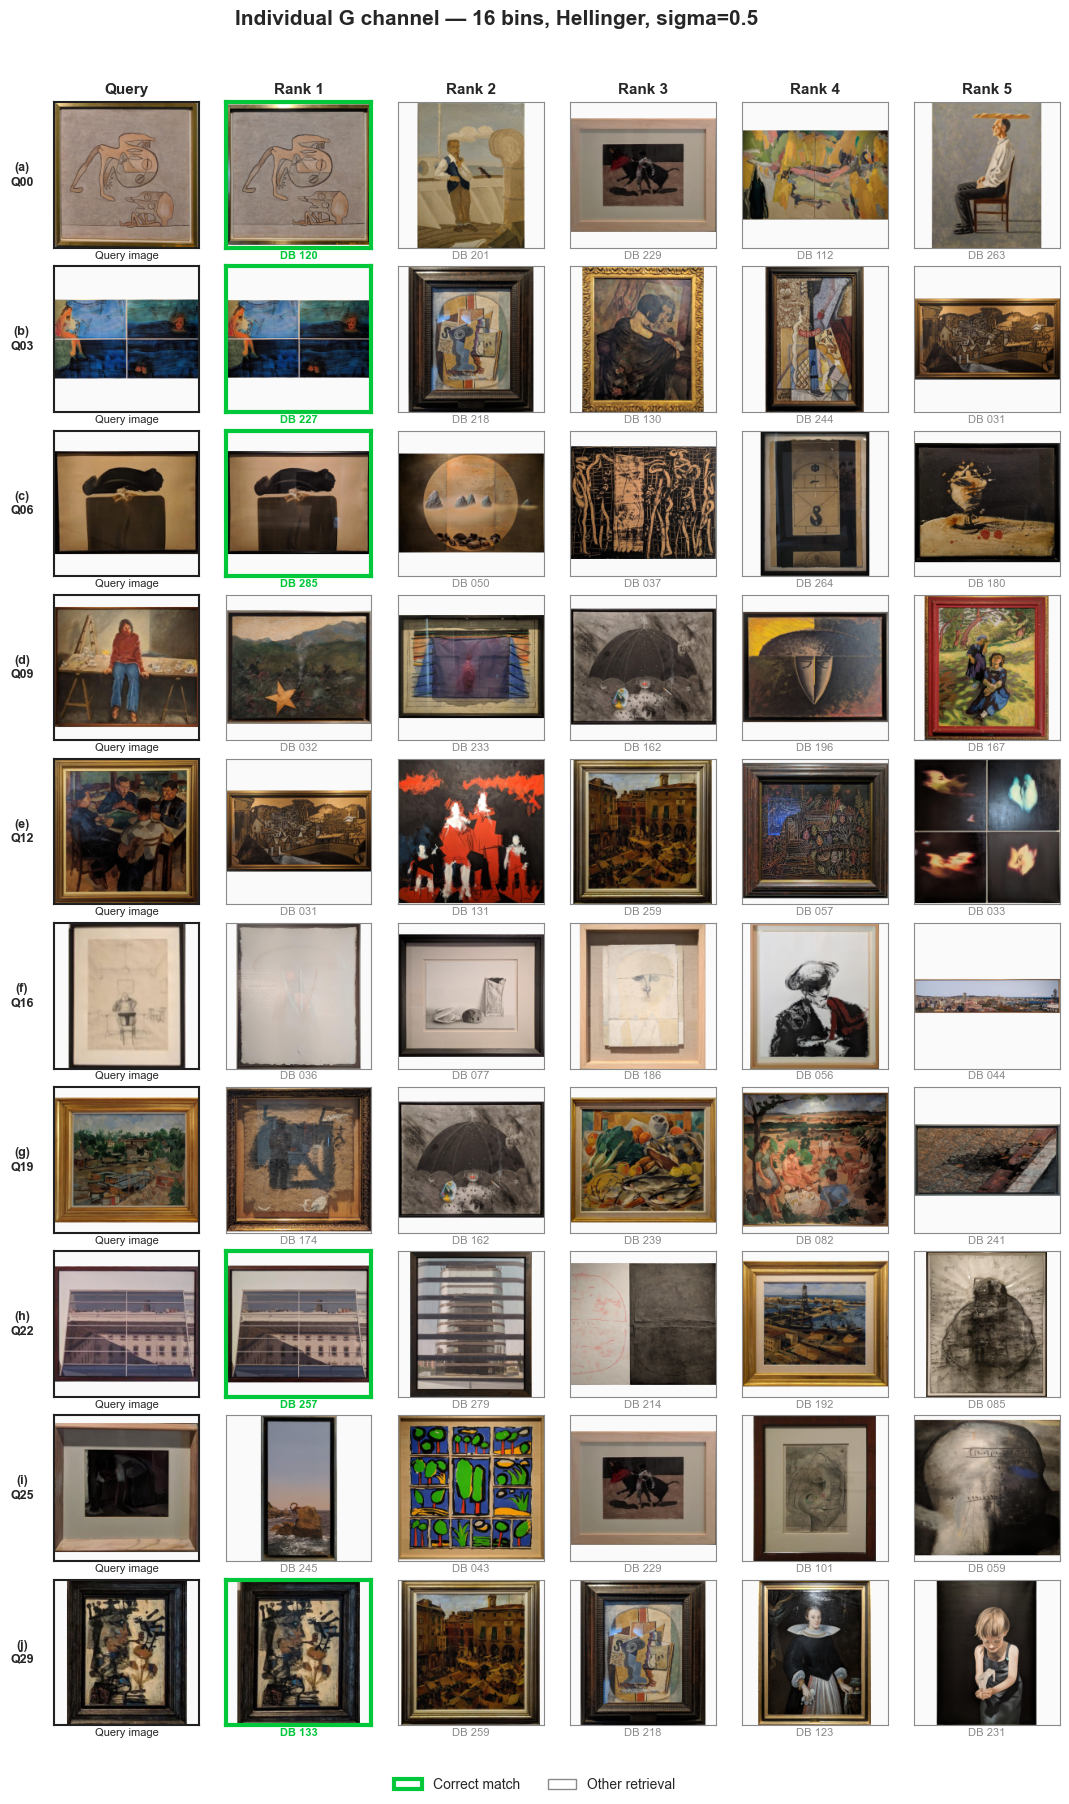

In [14]:
best_individual_rgb = rgb_tuned_results.iloc[0]
individual_rgb_evaluation = evaluate_configuration(
    RGB_DB, RGB_QUERIES, best_individual_rgb.channel,
    int(best_individual_rgb.bins), best_individual_rgb.metric,
    float(best_individual_rgb.sigma),
)

stacked_rgb_evaluation = evaluate_stacked_rgb(
    int(best_stacked_rgb.bins), best_stacked_rgb.metric, float(best_stacked_rgb.sigma)
)

best_overall = alternative_results.iloc[0]
best_overall_evaluation = evaluate_configuration(
    ALT_DB, ALT_QUERIES, best_overall.channel,
    int(best_overall.bins), best_overall.metric, float(best_overall.sigma),
)

display(pd.DataFrame([
    {
        "method": f"Individual {best_individual_rgb.channel}",
        "mAP@1": individual_rgb_evaluation["mAP@1"],
        "mAP@5": individual_rgb_evaluation["mAP@5"],
        "median GT rank": float(np.median(individual_rgb_evaluation["correct_ranks"])),
    },
    {
        "method": "Stacked RGB",
        "mAP@1": stacked_rgb_evaluation["mAP@1"],
        "mAP@5": stacked_rgb_evaluation["mAP@5"],
        "median GT rank": float(np.median(stacked_rgb_evaluation["correct_ranks"])),
    },
    {
        "method": f"Best {best_overall.channel}",
        "mAP@1": best_overall_evaluation["mAP@1"],
        "mAP@5": best_overall_evaluation["mAP@5"],
        "median GT rank": float(np.median(best_overall_evaluation["correct_ranks"])),
    },
]))

top1_agreement = np.mean(
    individual_rgb_evaluation["rankings"][:, 0]
    == best_overall_evaluation["rankings"][:, 0]
)
top5_overlap = np.mean([
    len(set(rgb[:5]) & set(best[:5])) / 5
    for rgb, best in zip(
        individual_rgb_evaluation["rankings"], best_overall_evaluation["rankings"]
    )
])
print(
    f"Individual RGB and {best_overall.channel} agree on the top result for "
    f"{top1_agreement:.1%} of queries; mean top-5 overlap is {top5_overlap:.1%}."
)


PAPER_GRID_COLORS = {
    "query": "#202020",
    "correct": "#00C83A",
    "other": "#8A8A8A",
}


def square_thumbnail(path, size=180, background=250):
    '''Create an aspect-preserving square thumbnail for display only.'''
    image = read_rgb(path)
    height, width = image.shape[:2]
    scale = min(size / width, size / height)
    target = (max(1, round(width * scale)), max(1, round(height * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(image, target, interpolation=interpolation)
    canvas = np.full((size, size, 3), background, dtype=np.uint8)
    top = (size - resized.shape[0]) // 2
    left = (size - resized.shape[1]) // 2
    canvas[top:top + resized.shape[0], left:left + resized.shape[1]] = resized
    return canvas


def style_paper_axis(axis, color, linewidth):
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(linewidth)


representative_queries = np.linspace(0, len(QUERY_PATHS) - 1, 10, dtype=int)
print("Displayed query indices:", representative_queries.tolist())


def plot_paper_grid(evaluation, title, query_indices=representative_queries, top_k=5):
    '''Plot ten representative queries and one method's top-k results.'''
    row_labels = list("abcdefghij")
    fig, axes = plt.subplots(
        len(query_indices), top_k + 1,
        figsize=(12, 18), dpi=100, facecolor="white",
    )

    for row, query_index in enumerate(query_indices):
        relevant = set(GROUND_TRUTH[query_index])
        query_axis = axes[row, 0]
        query_axis.imshow(square_thumbnail(QUERY_PATHS[query_index]))
        query_axis.set_ylabel(
            f"({row_labels[row]})\nQ{query_index:02d}",
            rotation=0, labelpad=23, va="center",
            fontsize=9, fontweight="bold",
        )
        query_axis.set_xlabel("Query image", fontsize=8, labelpad=2)
        style_paper_axis(query_axis, PAPER_GRID_COLORS["query"], 1.5)

        for rank in range(top_k):
            axis = axes[row, rank + 1]
            image_id = evaluation["rankings"][query_index, rank]
            is_correct = image_id in relevant
            color = PAPER_GRID_COLORS["correct"] if is_correct else PAPER_GRID_COLORS["other"]
            axis.imshow(square_thumbnail(DB_PATH_BY_ID[image_id]))
            axis.set_xlabel(
                f"DB {image_id:03d}",
                fontsize=8,
                labelpad=2,
                color=color,
                fontweight="bold" if is_correct else "normal",
            )
            style_paper_axis(axis, color, 3.0 if is_correct else 0.8)

        if row == 0:
            query_axis.set_title("Query", fontsize=11, fontweight="bold")
            for rank in range(top_k):
                axes[row, rank + 1].set_title(
                    f"Rank {rank + 1}", fontsize=11, fontweight="bold"
                )

    legend = [
        Patch(edgecolor=PAPER_GRID_COLORS["correct"], facecolor="white", linewidth=3, label="Correct match"),
        Patch(edgecolor=PAPER_GRID_COLORS["other"], facecolor="white", linewidth=1, label="Other retrieval"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=2, frameon=False, fontsize=10)
    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.995)
    plt.tight_layout(rect=(0.07, 0.025, 1, 0.985), h_pad=0.35, w_pad=0.25)
    plt.show()


rgb_title = (
    f"Individual {best_individual_rgb.channel} channel — "
    f"{int(best_individual_rgb.bins)} bins, {best_individual_rgb.metric}, "
    f"sigma={best_individual_rgb.sigma:g}"
)
plot_paper_grid(individual_rgb_evaluation, rgb_title)

# Retrieval examples: best overall descriptor

The same ten queries and row order are repeated for the best descriptor, enabling direct comparison with the RGB figure above.

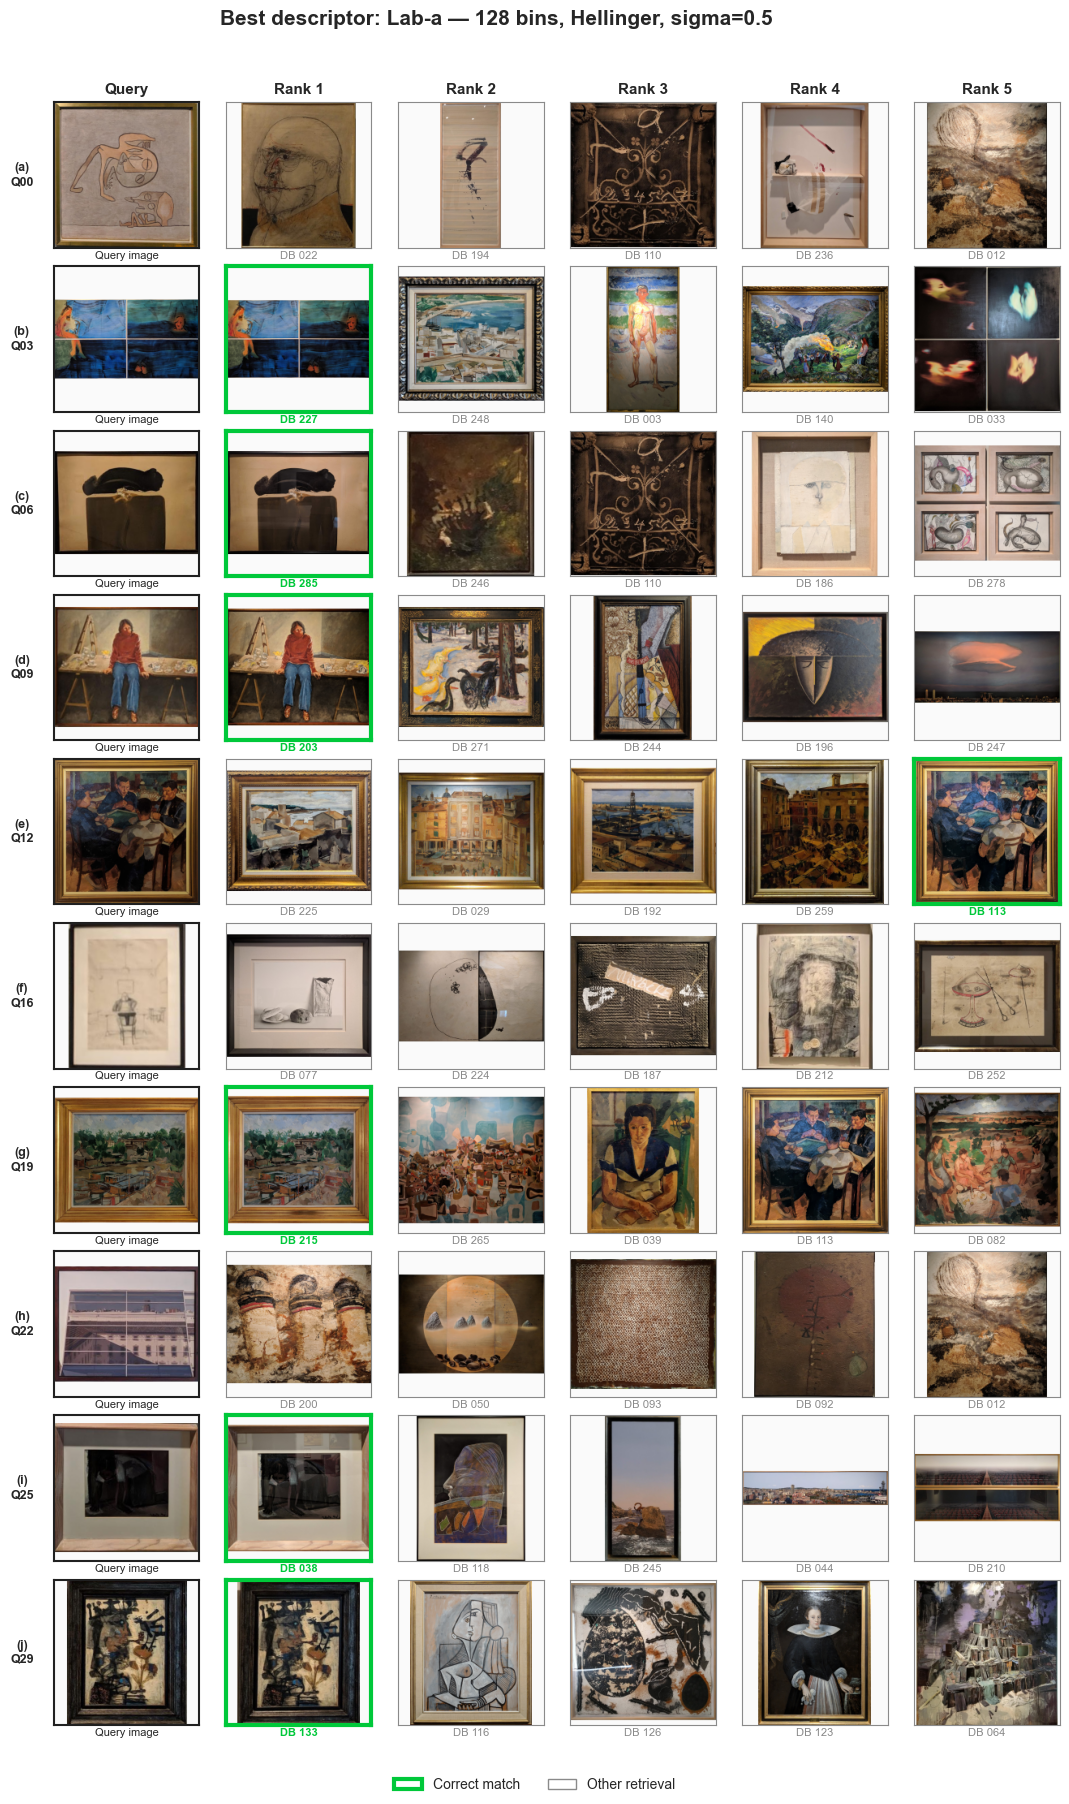

In [15]:
best_title = (
    f"Best descriptor: {best_overall.channel} — {int(best_overall.bins)} bins, "
    f"{best_overall.metric}, sigma={best_overall.sigma:g}"
)
plot_paper_grid(best_overall_evaluation, best_title)

# Findings

In [16]:
display(Markdown(
    f"- **Best individual RGB:** {best_individual_rgb.channel}, "
    f"{int(best_individual_rgb.bins)} bins, {best_individual_rgb.metric}, "
    f"sigma = {best_individual_rgb.sigma:g} "
    f"(mAP@1 = {individual_rgb_evaluation['mAP@1']:.3f}, "
    f"mAP@5 = {individual_rgb_evaluation['mAP@5']:.3f}).\n"
    f"- **Best stacked RGB:** {int(best_stacked_rgb.bins)} bins per channel, "
    f"{best_stacked_rgb.metric}, sigma = {best_stacked_rgb.sigma:g} "
    f"(mAP@1 = {stacked_rgb_evaluation['mAP@1']:.3f}, "
    f"mAP@5 = {stacked_rgb_evaluation['mAP@5']:.3f}).\n"
    f"- **Best overall descriptor:** {best_overall.channel}, "
    f"{int(best_overall.bins)} bins, {best_overall.metric}, "
    f"sigma = {best_overall.sigma:g} "
    f"(mAP@1 = {best_overall_evaluation['mAP@1']:.3f}, "
    f"mAP@5 = {best_overall_evaluation['mAP@5']:.3f})."
))

- **Best individual RGB:** G, 16 bins, Hellinger, sigma = 0.5 (mAP@1 = 0.333, mAP@5 = 0.357).
- **Best stacked RGB:** 8 bins per channel, Hellinger, sigma = 0 (mAP@1 = 0.433, mAP@5 = 0.450).
- **Best overall descriptor:** Lab-a, 128 bins, Hellinger, sigma = 0.5 (mAP@1 = 0.500, mAP@5 = 0.532).